In [14]:
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import spacy
import emoji
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import pickle
from keras.layers import Dense, Dropout, Conv1D, GlobalMaxPooling1D
from keras.models import Sequential
from sklearn.metrics import log_loss

In [11]:
#col = ['id','country','Label','Text']
data = pd.read_csv("C:/vscode/機器學習與黃聰明/preprocessed_data.csv",encoding = 'latin',header=None)

C:\Users\USER\AppData\Local\Temp\ipykernel_31044\3207876983.py:2: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("C:/vscode/機器學習與黃聰明/preprocessed_data.csv",encoding = 'latin',header=None)


In [13]:
data.columns = ['sentiment', 'id', 'date', 'query', 'user_id', 'text','Preprocessed Text']


In [14]:
data = data.iloc[1:1600001,:]

In [32]:
data.dropna(inplace=True)

In [33]:
# Preprocess Function
nlp = spacy.load("en_core_web_sm") 
def preprocess(text):
    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    
    return " ".join(filtered_tokens)

In [39]:


# 加載 SpaCy 模型
nlp = spacy.load("en_core_web_sm")

def replace_chat_words(text):
    """
    替換常見縮寫和聊天用語為完整表達。
    """
    chat_words = {
        "BRB": "Be right back",
        "BTW": "By the way",
        "OMG": "Oh my God/goodness",
        "TTYL": "Talk to you later",
        "OMW": "On my way",
        "SMH": "Shaking my head",
        "SMDH": "Shaking my darn head",
        "LOL": "Laugh out loud",
        "TBD": "To be determined",
        "IMHO": "In my humble opinion",
        "IMO": "In my opinion",
        "HMU": "Hit me up",
        "IIRC": "If I remember correctly",
        "LMK": "Let me know",
        "OG": "Original gangsters",
        "FTW": "For the win",
        "NVM": "Nevermind",
        "OOTD": "Outfit of the day",
        "NGL": "Not gonna lie",
        "RQ": "Real quick",
        "IYKYK": "If you know, you know",
        "ONG": "On God (I swear)",
        "YAAAS": "Yes!",
        "BRT": "Be right there",
        "SM": "So much",
        "IG": "I guess",
        "WYA": "Where you at",
        "ISTG": "I swear to God",
        "HBU": "How about you",
        "ATM": "At the moment",
        "ASAP": "As soon as possible",
        "FYI": "For your information"
    }
    for word, expanded_form in chat_words.items():
        pattern = r'\b' + re.escape(word) + r'\b'
        text = re.sub(pattern, expanded_form, text, flags=re.IGNORECASE)
    return text

def clean_text(text):
    """
    文本清理函數：處理表情符號、網址、提及、非文字字符等。
    """
    # 移除表情符號
    text = emoji.replace_emoji(text, replace="")
    # 移除網址和提及
    text = re.sub(r"@\S+|https?:\S+|http?:\S|[^A-Za-z0-9 ]+", " ", text)
    # 替換聊天用語
    text = replace_chat_words(text)
    return text.strip()

def preprocess(text):
    """
    預處理函數：清理文本並進行標記化、去停用詞、詞形還原。
    """
    # 清理文本
    cleaned_text = clean_text(text)
    # 使用 SpaCy 進行標記化、詞形還原和去停用詞
    doc = nlp(cleaned_text)
    filtered_tokens = [
        token.lemma_ for token in doc 
        if not token.is_stop and not token.is_punct
    ]
    return " ".join(filtered_tokens)

In [40]:
data['Preprocessed Text'] = data['text'].apply(preprocess)

In [42]:
output_path = "C:/vscode/機器學習與黃聰明/preprocessed_data.csv"
data.to_csv(output_path, index=False, encoding="latin")

print(f"數據已成功保存至 {output_path}")

數據已成功保存至 C:/vscode/機器學習與黃聰明/preprocessed_data.csv


In [17]:
data = pd.read_csv("C:/vscode\h_p\preprocessed_data.csv",encoding="latin1")

<>:1: SyntaxWarning: invalid escape sequence '\h'
<>:1: SyntaxWarning: invalid escape sequence '\h'
C:\Users\USER\AppData\Local\Temp\ipykernel_46760\1357089396.py:1: SyntaxWarning: invalid escape sequence '\h'
  data = pd.read_csv("C:/vscode\h_p\preprocessed_data.csv",encoding="latin1")


In [18]:
data

,sentiment,id,date,query,user_id,text,Preprocessed Text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",Awww s bummer shoulda get David Carr Day ...
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,upset t update Facebook texte cry result S...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,dive time ball manage save 50 rest bound
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,body feel itchy like fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",s behave m mad t
...,...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...,wake have school good feeling
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...,TheWDB com cool hear old Walt interview
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...,ready MoJo Makeover ask detail
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...,happy 38th birthday boo alll time Tupac Amar...


In [7]:
data['sentiment'] = data['sentiment'].replace(4, 1)

In [8]:
data = data.dropna()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    data['Preprocessed Text'], data['sentiment'], test_size=0.2, random_state=42
)

NameError: name 'train_test_split' is not defined

In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(
    data['Preprocessed Text'], data['sentiment'], test_size=0.2, random_state=42
)
# 特徵提取
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tf = vectorizer.fit_transform(X_train).astype(np.float32)
X_test_tf = vectorizer.transform(X_test).astype(np.float32)
y_train = y_train.astype(np.float32)
y_test = y_test.astype(np.float32)

In [11]:
# 儲存 vectorizer
with open("tfidf_vectorizer.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

# 儲存處理後的資料
np.savez_compressed("training_data.npz",
                    X_train=X_train_tf.toarray(),
                    X_test=X_test_tf.toarray(),
                    y_train=y_train,
                    y_test=y_test)

In [2]:
import pickle

with open("tfidf_vectorizer.pkl", "rb") as f:
    vectorizer = pickle.load(f)
import numpy as np

# 載入資料
data = np.load("training_data.npz")

# 取出各資料陣列
X_train_tf = data["X_train"]
X_test_tf = data["X_test"]
y_train = data["y_train"]
y_test = data["y_test"]


In [12]:
X_train_tf

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, GlobalMaxPooling1D, Dense, Dropout

# 定義 CNN 模型
model = Sequential([
    Conv1D(filters=128, kernel_size=3, activation='relu', input_shape=(3000, 1)),  # 修改輸入形狀
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # 適合二元分類
])

# 編譯模型
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 查看模型結構
model.summary()


c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2998, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,833 (34.50 KB)

 Trainable params: 8,833 (34.50 KB)

 Non-trainable params: 0 (0.00 B)

In [86]:
class SparseDataGenerator(Sequence):
    def __init__(self, X, y, batch_size, **kwargs):
        super().__init__(**kwargs)
        self.X = X
        self.y = y
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(self.X.shape[0] / self.batch_size))

    def __getitem__(self, index):
        # 僅轉換當前批次為稠密矩陣
        X_batch = self.X[index * self.batch_size:(index + 1) * self.batch_size].toarray().astype(np.float32)
        y_batch = self.y[index * self.batch_size:(index + 1) * self.batch_size].astype(np.float32)
        return X_batch[..., np.newaxis], y_batch  # 增加 CNN 所需的通道維度

# 定義模型
model = Sequential([
    Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(3000, 1)),
    GlobalMaxPooling1D(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 創建數據生成器
batch_size = 128
train_gen = SparseDataGenerator(X_train_tf, y_train, batch_size)
val_gen = SparseDataGenerator(X_test_tf, y_test, batch_size)

# 設置學習率調度
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch):
    initial_lr = 1e-3
    drop = 0.5
    epochs_drop = 5
    return initial_lr * (drop ** (epoch // epochs_drop)) 

lr_callback = LearningRateScheduler(lr_schedule)

# 訓練模型
history = model.fit(train_gen, epochs=10, validation_data=val_gen, callbacks=[lr_callback])

Epoch 1/10
7456/7456 ━━━━━━━━━━━━━━━━━━━━ 619s 83ms/step - accuracy: 0.5111 - loss: 0.6928 - val_accuracy: 0.5185 - val_loss: 0.6922 - learning_rate: 0.0010
Epoch 2/10
7456/7456 ━━━━━━━━━━━━━━━━━━━━ 620s 83ms/step - accuracy: 0.5172 - loss: 0.6924 - val_accuracy: 0.5212 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 3/10
7456/7456 ━━━━━━━━━━━━━━━━━━━━ 623s 84ms/step - accuracy: 0.5170 - loss: 0.6924 - val_accuracy: 0.5214 - val_loss: 0.6919 - learning_rate: 0.0010
Epoch 4/10
7456/7456 ━━━━━━━━━━━━━━━━━━━━ 687s 92ms/step - accuracy: 0.5170 - loss: 0.6923 - val_accuracy: 0.5213 - val_loss: 0.6920 - learning_rate: 0.0010
Epoch 5/10
7456/7456 ━━━━━━━━━━━━━━━━━━━━ 645s 86ms/step - accuracy: 0.5176 - loss: 0.6923 - val_accuracy: 0.5216 - val_loss: 0.6918 - learning_rate: 0.0010
Epoch 6/10
7456/7456 ━━━━━━━━━━━━━━━━━━━━ 626s 84ms/step - accuracy: 0.5182 - loss: 0.6922 - val_accuracy: 0.5215 - val_loss: 0.6918 - learning_rate: 5.0000e-04
Epoch 7/10
7456/7456 ━━━━━━━━━━━━━━━━━━━━ 706s 95ms/st

In [5]:
from keras_tuner import HyperModel, RandomSearch
from tensorflow.keras.utils import Sequence
class DenseDataGenerator(Sequence):
    def __init__(self, X, y, batch_size, **kwargs):
        super().__init__(**kwargs)
        self.X = X.astype(np.float32)
        self.y = y.astype(np.float32)
        self.batch_size = batch_size

    def __len__(self):
        return int(np.ceil(self.X.shape[0] / self.batch_size))

    def __getitem__(self, index):
        X_batch = self.X[index * self.batch_size:(index + 1) * self.batch_size]
        y_batch = self.y[index * self.batch_size:(index + 1) * self.batch_size]
        return X_batch[..., np.newaxis], y_batch

# 創建數據生成器
batch_size = 128
train_gen = DenseDataGenerator(X_train_tf, y_train, batch_size=128)
val_gen = DenseDataGenerator(X_test_tf, y_test, batch_size=128)
class MyHyperModel(HyperModel):
    def build(self, hp):
        model = Sequential()
        model.add(Conv1D(
            filters=hp.Choice('filters', [64, 128, 256]),
            kernel_size=hp.Choice('kernel_size', [3, 5, 7]),
            activation='relu',
            input_shape=(3000, 1)))
        model.add(GlobalMaxPooling1D())
        model.add(Dropout(hp.Choice('dropout_rate', [0.3, 0.5])))
        model.add(Dense(64, activation='relu'))
        model.add(Dropout(hp.Choice('dropout_rate2', [0.3, 0.5])))
        model.add(Dense(1, activation='sigmoid'))

        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])
        return model

# 建立 tuner
tuner = RandomSearch(
    MyHyperModel(),
    objective='val_accuracy',
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    directory='C:/vscode/h_p/tuner_log',
    project_name='sentiment_cnn'
)

# 開始調參
tuner.search(train_gen, validation_data=val_gen, epochs=5)


Trial 1 Complete [00h 29m 18s]
val_accuracy: 0.5178375840187073

Best val_accuracy So Far: 0.5178375840187073
Total elapsed time: 00h 29m 18s

Search: Running Trial #2

Value             |Best Value So Far |Hyperparameter
256               |64                |filters
5                 |3                 |kernel_size
0.3               |0.5               |dropout_rate
0.3               |0.3               |dropout_rate2

Epoch 1/5
9941/9941 ━━━━━━━━━━━━━━━━━━━━ 1534s 154ms/step - accuracy: 0.5151 - loss: 0.6925 - val_accuracy: 0.5188 - val_loss: 0.6920
Epoch 2/5
9941/9941 ━━━━━━━━━━━━━━━━━━━━ 1537s 155ms/step - accuracy: 0.5202 - loss: 0.6919 - val_accuracy: 0.5199 - val_loss: 0.6920
Epoch 3/5
9941/9941 ━━━━━━━━━━━━━━━━━━━━ 1536s 155ms/step - accuracy: 0.5206 - loss: 0.6919 - val_accuracy: 0.5152 - val_loss: 0.6926
Epoch 4/5
9941/9941 ━━━━━━━━━━━━━━━━━━━━ 1555s 156ms/step - accuracy: 0.5197 - loss: 0.6920 - val_accuracy: 0.5193 - val_loss: 0.6919
Epoch 5/5
4979/9941 ━━━━━━━━━━━━━━━━━━━━ 1

KeyboardInterrupt: 

In [ ]:
# 取得最佳模型（第 1 名）
best_model = tuner.get_best_models(num_models=1)[0]

# 儲存模型為 .keras 格式（建議）
best_model.save("best_sentiment_model.keras")

In [ ]:
model = load_model("sentiment_CNNmodel.keras")

# 繼續訓練
model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_val, y_val))

NameError: name 'model' is not defined

In [ ]:
# 在驗證集上評估模型
test_loss, test_accuracy = model.evalㄣㄣㄣuate(val_gen)
print(f"測試損失: {test_loss:.4f}")
print(f"測試準確率: {test_accuracy:.4f}")


4971/4971 ━━━━━━━━━━━━━━━━━━━━ 94s 19ms/step - accuracy: 0.5211 - loss: 0.6919
測試損失: 0.6919
測試準確率: 0.5211


In [150]:
# 在驗證集上評估模型
train_loss, train_accuracy = model.evaluate(train_gen)
print(f"測試損失: {train_loss:.4f}")
print(f"測試準確率: {train_accuracy:.4f}")


7456/7456 ━━━━━━━━━━━━━━━━━━━━ 143s 19ms/step - accuracy: 0.5204 - loss: 0.6919
測試損失: 0.6919
測試準確率: 0.5199


In [ ]:
# 獲取預測結果
y_pred = model.predict(train_gen)

# 二元分類轉換為 0 和 1
y_pred_binary = (y_pred > 0.5).astype(int)


# 計算混淆矩陣
conf_matrix_train_CNN = confusion_matrix(y_train, y_pred_binary)


7456/7456 ━━━━━━━━━━━━━━━━━━━━ 135s 18ms/step
混淆矩陣:
[[211541 106227]
 [198451 119965]]
分類報告:
              precision    recall  f1-score   support

         0.0       0.52      0.66      0.58    477674
         1.0       0.53      0.38      0.44    476600

    accuracy                           0.52    954274
   macro avg       0.52      0.52      0.51    954274
weighted avg       0.52      0.52      0.51    954274



In [157]:

print("混淆矩陣:")
print(conf_matrix_train_CNN )

# 分類報告
print("分類報告:")
print(classification_report(y_train, y_pred_binary))

混淆矩陣:
[[317369 160305]
 [297796 178804]]
分類報告:
              precision    recall  f1-score   support

         0.0       0.52      0.66      0.58    477674
         1.0       0.53      0.38      0.44    476600

    accuracy                           0.52    954274
   macro avg       0.52      0.52      0.51    954274
weighted avg       0.52      0.52      0.51    954274



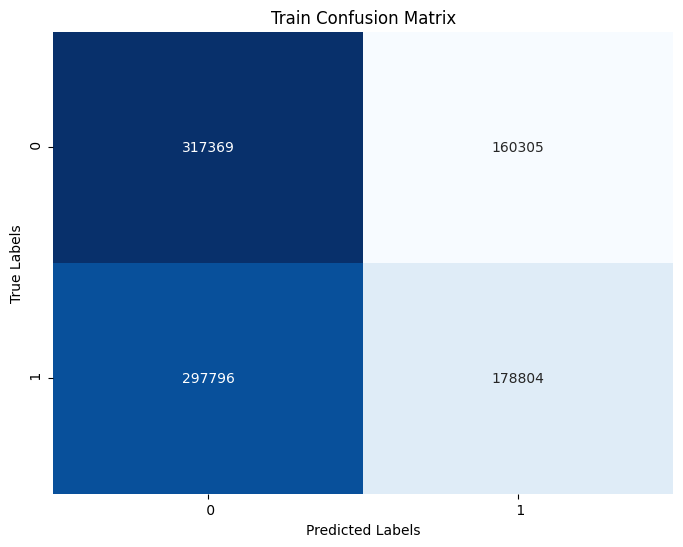

In [156]:
# 定義類別名稱（根據數據實際類別調整）
class_names = [' 0', ' 1']

# 繪製熱力圖，並加上標籤
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_train_CNN , annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Train Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [153]:
# 獲取預測結果
y_pred = model.predict(val_gen)

# 二元分類轉換為 0 和 1
y_pred_binary = (y_pred > 0.5).astype(int)


# 計算混淆矩陣
conf_matrix = confusion_matrix(y_test, y_pred_binary)
print("混淆矩陣:")
print(conf_matrix)

# 分類報告
print("分類報告:")
print(classification_report(y_test, y_pred_binary))



4971/4971 ━━━━━━━━━━━━━━━━━━━━ 90s 18ms/step
混淆矩陣:
[[211541 106227]
 [198451 119965]]
分類報告:
              precision    recall  f1-score   support

           0       0.52      0.67      0.58    317768
           1       0.53      0.38      0.44    318416

    accuracy                           0.52    636184
   macro avg       0.52      0.52      0.51    636184
weighted avg       0.52      0.52      0.51    636184



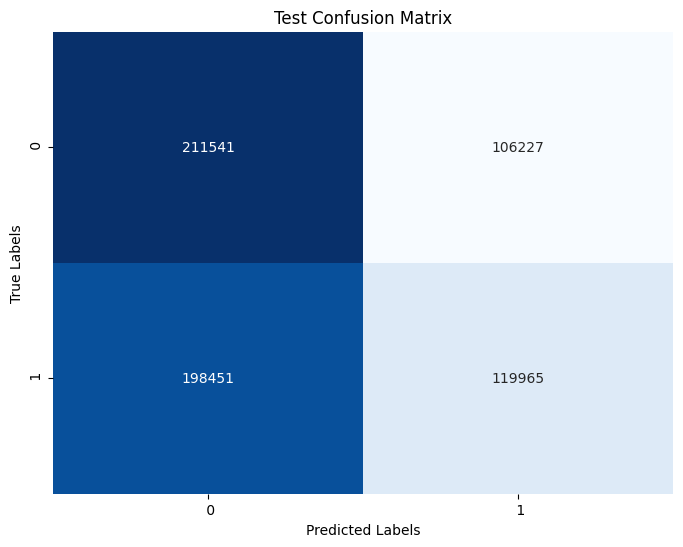

In [154]:
# 定義類別名稱（根據數據實際類別調整）
class_names = [' 0', ' 1']

# 繪製熱力圖，並加上標籤
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

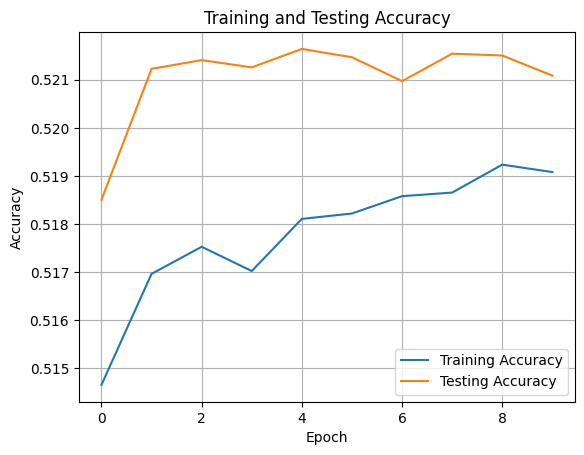

In [179]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Testing Accuracy')
plt.title('Training and Testing Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()



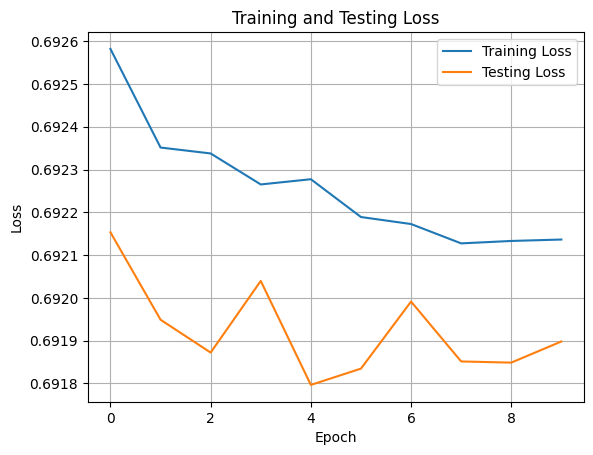

In [180]:
# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Testing Loss')
plt.title('Training and Testing Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()


In [6]:
# 將標籤轉換為整數類型
y_train = y_train.astype(int)
y_test = y_test.astype(int)


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report

for alpha in [1.0, 0.5, 0.1, 0.01]:
    nb_model = MultinomialNB(alpha=alpha)
    nb_model.fit(X_train_tf, y_train)
    y_pred = nb_model.predict(X_test_tf)
    
    print(f"--- alpha = {alpha} ---")
    print(classification_report(y_test, y_pred, digits=4))


--- alpha = 1.0 ---
              precision    recall  f1-score   support

           0     0.7428    0.7531    0.7479    158502
           1     0.7513    0.7411    0.7462    159590

    accuracy                         0.7470    318092
   macro avg     0.7471    0.7471    0.7470    318092
weighted avg     0.7471    0.7470    0.7470    318092

--- alpha = 0.5 ---
              precision    recall  f1-score   support

           0     0.7428    0.7530    0.7479    158502
           1     0.7513    0.7411    0.7461    159590

    accuracy                         0.7470    318092
   macro avg     0.7470    0.7470    0.7470    318092
weighted avg     0.7471    0.7470    0.7470    318092

--- alpha = 0.1 ---
              precision    recall  f1-score   support

           0     0.7428    0.7529    0.7478    158502
           1     0.7512    0.7410    0.7461    159590

    accuracy                         0.7470    318092
   macro avg     0.7470    0.7470    0.7470    318092
weighted avg  

In [143]:
# 建立 Multinomial Naive Bayes 模型
nb_model = MultinomialNB()

# 訓練模型
nb_model.fit(X_train_tf, y_train)

# 預測
y_pred = nb_model.predict(X_test_tf)


In [161]:
from sklearn.metrics import accuracy_score, log_loss, classification_report

# 測試集預測
y_pred = nb_model.predict(X_test_tf)

# 測試集概率預測
y_pred_prob = nb_model.predict_proba(X_test_tf)



# 評估結果
print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))



Testing Accuracy: 0.7470747456710637
Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.75      0.75    317768
           1       0.75      0.74      0.75    318416

    accuracy                           0.75    636184
   macro avg       0.75      0.75      0.75    636184
weighted avg       0.75      0.75      0.75    636184



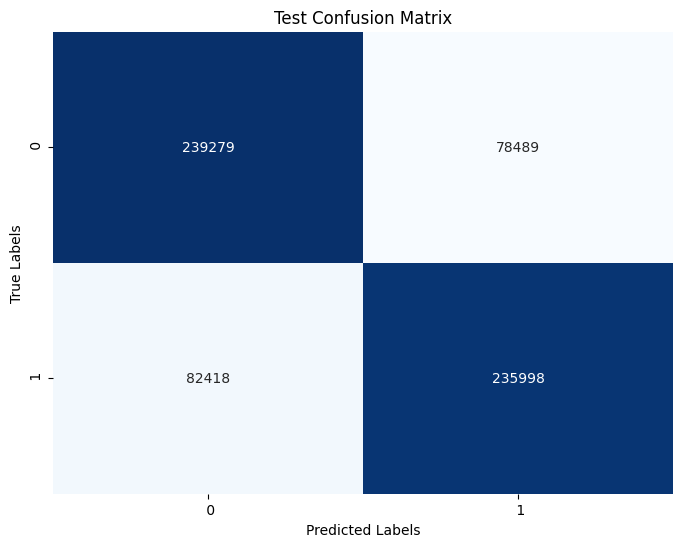

In [163]:
# 計算混淆矩陣
conf_matrix_bayes_test= confusion_matrix(y_test, y_pred)

# 定義類別名稱（根據數據的實際類別進行調整）
class_names = [' 0', ' 1']  # 替換為實際類別名稱

# 繪製熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bayes_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [164]:
# 評估結果
y_pred = nb_model.predict(X_train_tf)
# 訓練集損失
y_train_pred_prob = nb_model.predict_proba(X_train_tf)


print("Training Accuracy:", accuracy_score(y_train, y_pred))
print("Classification Report:\n", classification_report(y_train, y_pred))


Training Accuracy: 0.7480377753140084
Classification Report:
               precision    recall  f1-score   support

         0.0       0.75      0.75      0.75    477674
         1.0       0.75      0.74      0.75    476600

    accuracy                           0.75    954274
   macro avg       0.75      0.75      0.75    954274
weighted avg       0.75      0.75      0.75    954274



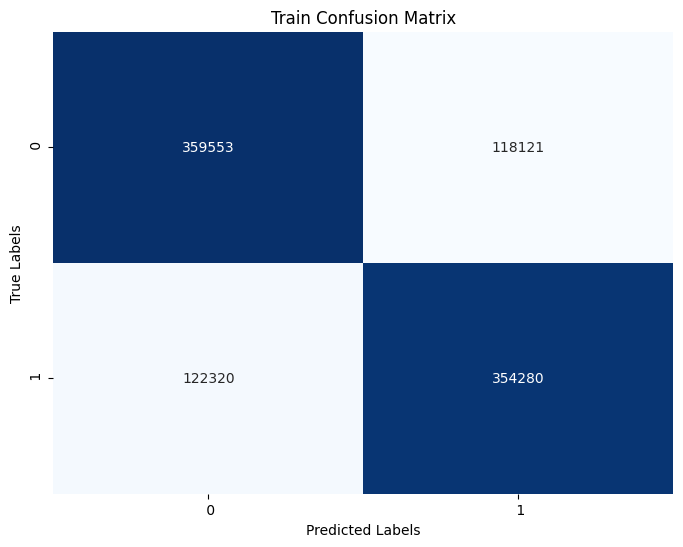

In [166]:
# 計算混淆矩陣
conf_matrix_bayes_train= confusion_matrix(y_train, y_pred)

# 定義類別名稱（根據數據的實際類別進行調整）
class_names = [' 0', ' 1']  # 替換為實際類別名稱

# 繪製熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_bayes_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Train Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [94]:
# 保存模型到文件
with open('C:/vscode/機器學習與黃聰明/multinomial_nb_model.pkl', 'wb') as file:
    pickle.dump(nb_model, file)
print("模型已保存到 'multinomial_nb_model.pkl'")

模型已保存到 'multinomial_nb_model.pkl'


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    'max_depth': [3, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42),
                           param_grid,
                           cv=5,
                           scoring='accuracy')

grid_search.fit(X_train_tf, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_tf)

In [5]:
import pickle

# 儲存最佳模型
with open("best_tree_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

In [6]:
# 最佳參數組合
print("最佳參數組合：", grid_search.best_params_)

# 交叉驗證中最高的平均準確率
print("最佳交叉驗證準確率：", grid_search.best_score_)

# 測試集準確率
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("測試集準確率：", accuracy_score(y_test, y_pred))
print("分類報告：")
print(classification_report(y_test, y_pred, digits=4))
print("混淆矩陣：")
print(confusion_matrix(y_test, y_pred))


最佳參數組合： {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1}
最佳交叉驗證準確率： 0.598154932400306
測試集準確率： 0.5997918841089999
分類報告：
              precision    recall  f1-score   support

         0.0     0.7895    0.2684    0.4006    158502
         1.0     0.5611    0.9289    0.6996    159590

    accuracy                         0.5998    318092
   macro avg     0.6753    0.5987    0.5501    318092
weighted avg     0.6749    0.5998    0.5506    318092

混淆矩陣：
[[ 42540 115962]
 [ 11341 148249]]


In [ ]:


dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_tf, y_train)
y_pred = dt_model.predict(X_test_tf)

In [97]:
# 保存模型到文件
with open('C:/vscode/機器學習與黃聰明/dt_model.pkl', 'wb') as file:
    pickle.dump(dt_model, file)
print("模型已保存到 'dt_model.pkl'")

模型已保存到 'dt_model.pkl'


In [167]:
# 評估結果
y_pred = dt_model.predict(X_train_tf)
# 訓練集損失
y_train_pred_prob = dt_model.predict_proba(X_train_tf)
train_loss = log_loss(y_train, y_train_pred_prob)

print("Training Accuracy:", accuracy_score(y_train, y_pred))
print(f"Training Loss: {train_loss:.4f}")
print("Classification Report:\n", classification_report(y_train, y_pred))


Training Accuracy: 0.9662874604149332
Training Loss: 0.0649
Classification Report:
               precision    recall  f1-score   support

         0.0       0.97      0.96      0.97    477674
         1.0       0.96      0.97      0.97    476600

    accuracy                           0.97    954274
   macro avg       0.97      0.97      0.97    954274
weighted avg       0.97      0.97      0.97    954274



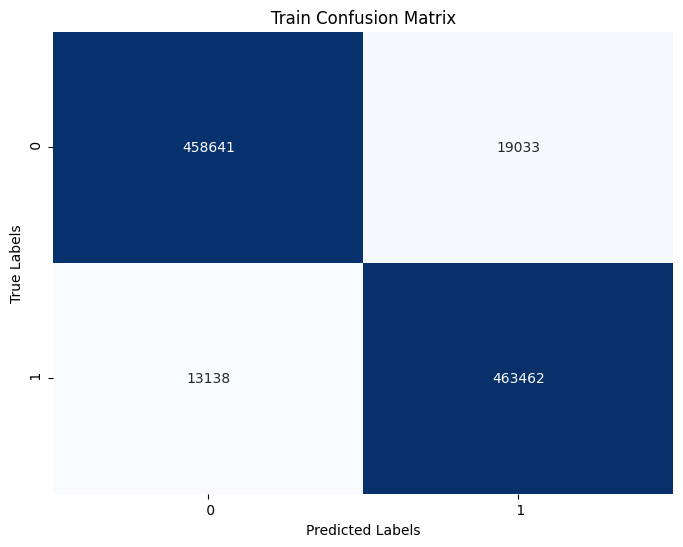

In [168]:
# 計算混淆矩陣
conf_matrix_dt_train= confusion_matrix(y_train, y_pred)

# 定義類別名稱（根據數據的實際類別進行調整）
class_names = [' 0', ' 1']  # 替換為實際類別名稱

# 繪製熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Train Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [169]:
# 評估結果
y_pred = dt_model.predict(X_test_tf)

# 測試集損失
y_pred_prob = dt_model.predict_proba(X_test_tf)
test_loss = log_loss(y_test, y_pred_prob)



print("Testing Accuracy:", accuracy_score(y_test, y_pred))
print(f"Testing Loss: {test_loss:.4f}")
print("Classification Report:\n", classification_report(y_test, y_pred))


Testing Accuracy: 0.7048542560014084
Testing Loss: 9.5221
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.70      0.70    317768
           1       0.70      0.71      0.71    318416

    accuracy                           0.70    636184
   macro avg       0.70      0.70      0.70    636184
weighted avg       0.70      0.70      0.70    636184



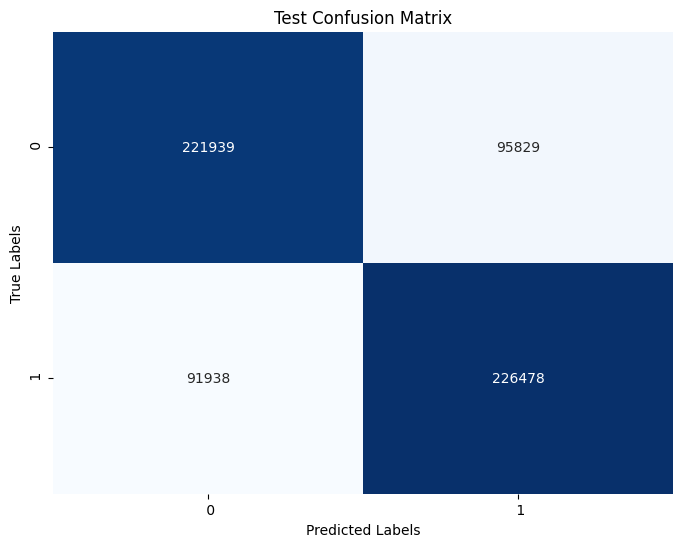

In [171]:
# 計算混淆矩陣
conf_matrix_dt_test= confusion_matrix(y_test, y_pred)

# 定義類別名稱（根據數據的實際類別進行調整）
class_names = [' 0', ' 1']  # 替換為實際類別名稱

# 繪製熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_dt_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
#不要執行!
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_features, y_train)
y_pred = rf_model.predict(X_test_features)

In [ ]:
# 保存模型到文件
with open('C:/vscode/機器學習與黃聰明/rf_model.pkl', 'wb') as file:
    pickle.dump(rf_model, file)
print("模型已保存到 'rf_model.pkl'")

In [173]:
# 分割數據集
X_train, X_test, y_train, y_test = train_test_split(
    data['Preprocessed Text'], data['sentiment'], test_size=0.2, random_state=42
)
vectorizer = CountVectorizer()
X_train_features = vectorizer.fit_transform(X_train)
X_test_features = vectorizer.transform(X_test) 
y_test_rf = np.array(y_test)
y_train_rf = np.array(y_train)


In [174]:
y_test_rf = y_test_rf.astype(str)  # 確保所有值為字符串
y_test_rf = y_test_rf.astype(int)  # 將字符串轉換為整數
y_train_rf = y_train_rf.astype(str)  # 確保所有值為字符串
y_train_rf = y_train_rf.astype(int)  # 將字符串轉換為整數

In [119]:
print("y_test_rf type:", type(y_test_rf))
print("y_pred type:", type(y_pred))
print("Unique values in y_test_rf:", set(y_test_rf))
print("Unique values in y_pred:", set(y_pred))


y_test_rf type: <class 'numpy.ndarray'>
y_pred type: <class 'numpy.ndarray'>
Unique values in y_test_rf: {0, 1}
Unique values in y_pred: {0, 1}


In [175]:
# 評估結果
# 測試集損失
y_pred = rf_model.predict(X_test_features)
y_pred_prob = rf_model.predict_proba(X_test_features)
test_loss = log_loss(y_test_rf, y_pred_prob)

print("Testing Accuracy:", accuracy_score(y_test_rf, y_pred))
print(f"Testing Loss: {test_loss:.4f}")
print("Classification Report:\n", classification_report(y_test_rf, y_pred))



Testing Accuracy: 0.7643354752713052
Testing Loss: 0.5326
Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.78      0.77    158502
           1       0.77      0.75      0.76    159590

    accuracy                           0.76    318092
   macro avg       0.76      0.76      0.76    318092
weighted avg       0.76      0.76      0.76    318092



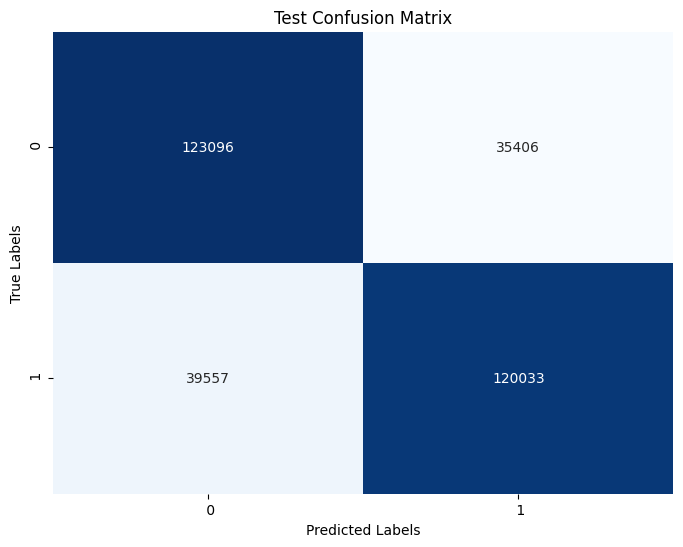

In [176]:
# 計算混淆矩陣
conf_matrix_rf_test= confusion_matrix(y_test_rf, y_pred)

# 定義類別名稱（根據數據的實際類別進行調整）
class_names = [' 0', ' 1']  # 替換為實際類別名稱

# 繪製熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_test, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [129]:
# 評估結果
y_pred_train = rf_model.predict(X_train_features)
# 訓練集損失
y_train_pred_prob = rf_model.predict_proba(X_train_features)
train_loss = log_loss(y_train_rf, y_train_pred_prob)



print("Training Accuracy:", accuracy_score(y_train_rf,y_pred_train))
print(f"Training Loss: {train_loss:.4f}")
print("Classification Report:\n", classification_report(y_train_rf, y_pred_train))


Training Accuracy: 0.9859780912096048
Training Loss: 0.1527
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99    636940
           1       0.99      0.99      0.99    635426

    accuracy                           0.99   1272366
   macro avg       0.99      0.99      0.99   1272366
weighted avg       0.99      0.99      0.99   1272366



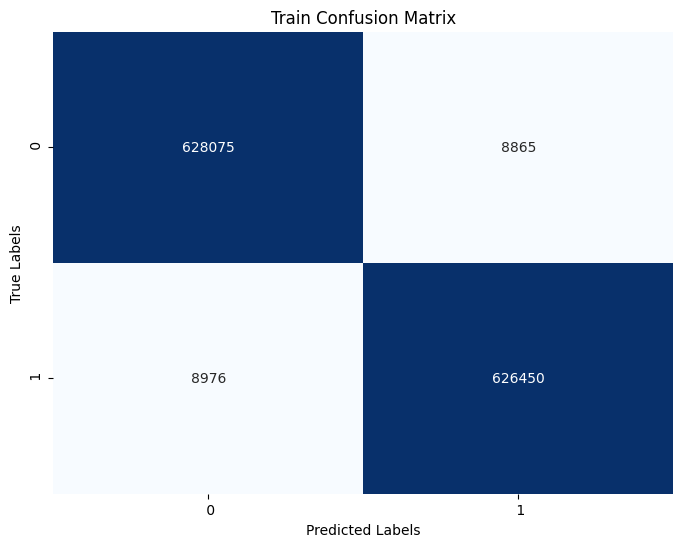

In [181]:
# 計算混淆矩陣
conf_matrix_rf_train= confusion_matrix(y_train_rf, y_pred_train)

# 定義類別名稱（根據數據的實際類別進行調整）
class_names = [' 0', ' 1']  # 替換為實際類別名稱

# 繪製熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_rf_train, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=class_names, yticklabels=class_names)
plt.title('Train Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [8]:
from transformers import BertTokenizer, TFBertForSequenceClassification
from transformers import Trainer, TrainingArguments

In [10]:
from transformers import DistilBertTokenizerFast, TFDistilBertForSequenceClassification
import tensorflow as tf

# 1. 載入 tokenizer 與模型
model_name = "distilbert-base-uncased"
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)
model = TFDistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

c:\Users\USER\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\USER\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

KeyboardInterrupt: 